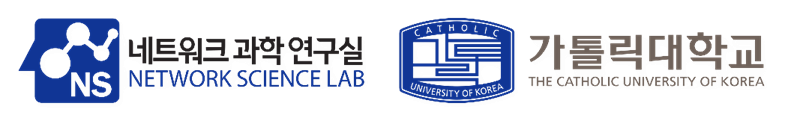

# Week 4: Scalable Graph Neural Networks 

- **Node-wise:** GraphSAGE
- **Layer-wise:** FastGCN, ASGCN
- **Graph-wise:** GraphSAINT, ClusterGCN


## 1. Setup




In [ ]:
DATASET_NAME = "Cora"

import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import add_self_loops, degree, subgraph

SEED = 42
EPOCHS = 40
HIDDEN = 64
DROPOUT = 0.5
LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 128

# GraphSAGE: neighbors kept at hop 1, then at hop 2.
FANOUTS = [10, 10]
# FastGCN: one shared sample.
FASTGCN_SAMPLES = 400
# ASGCN: nodes drawn for the input layer, then the hidden layer.
LAYER_SAMPLES = [128, 64]
# GraphSAINT random walks.
WALK_LENGTH = 2
SAINT_STEPS = 5
SAMPLE_COVERAGE = 20
# ClusterGCN: partition once, then glue a few clusters into each batch.
NUM_CLUSTERS = 8
CLUSTERS_PER_BATCH = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_everything()
print(f"PyTorch {torch.__version__} | device {DEVICE}")


/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


PyTorch 2.14.0+cu130 | device cuda


## Dataset

PyTorch Geometric stores each undirected edge in both directions, so the edge count is about twice the number of unique links. The public split labels 20 nodes per class for training and holds out the rest for validation and test.


In [2]:
dataset = Planetoid(root="data", name=DATASET_NAME, split="public", transform=NormalizeFeatures())
data = dataset[0]
data.y = data.y.view(-1)

print(f"Dataset: {DATASET_NAME}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Node feature length: {dataset.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")
print(
    "Train / val / test nodes: "
    f"{int(data.train_mask.sum())} / {int(data.val_mask.sum())} / {int(data.test_mask.sum())}"
)


Dataset: Cora
Number of nodes: 2708
Number of edges: 10556
Node feature length: 1433
Number of classes: 7
Train / val / test nodes: 140 / 500 / 1000


## Training loop

Training uses the sampler. Validation and test do not: each model is scored with a full-graph forward pass, so the accuracy is not a noisy sample. We keep the epoch with the best validation accuracy and report.


In [3]:
results = {}


def accuracies(pred):
    scores = {}
    for split, mask in (("train", data.train_mask), ("val", data.val_mask), ("test", data.test_mask)):
        correct = pred[mask] == data.y[mask]
        scores[split] = correct.float().mean().item()
    return scores


def plot_history(history, name):
    epochs = [row[0] for row in history]
    losses = [row[1] for row in history]
    val_scores = [row[2] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(epochs, losses, color="#2563eb")
    axes[0].set(title=f"{name} training loss", xlabel="Epoch", ylabel="Loss")
    axes[1].plot(epochs, val_scores, color="#d97706")
    axes[1].set(title=f"{name} validation accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
    for ax in axes:
        ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def fit(name, model, train_epoch, predict):
    """Train, keep the best validation epoch, and score that checkpoint on the test nodes."""
    best_val = -1.0
    best_epoch = 0
    best_state = None
    history = []
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch()
        scores = accuracies(predict())
        history.append((epoch, loss, scores["val"]))
        if scores["val"] > best_val:
            best_val = scores["val"]
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | loss {loss:.3f} | validation {scores['val']:.1%}")
    model.load_state_dict(best_state)
    final = accuracies(predict())
    results[name] = final
    print(
        f"{name} | best epoch {best_epoch} | "
        f"train {final['train']:.1%} | val {final['val']:.1%} | test {final['test']:.1%}"
    )
    plot_history(history, name)


# 1. GraphSAGE

A full-batch GCN builds a computation graph with every neighbor, then every neighbor of those neighbors. GraphSAGE replaces each of those sets by a fixed-size sample. For a target $v$ and a fanout $s_k$ at layer $k$, $\mathcal{S}_k(v)$ is a uniform draw of $s_k$ neighbors of $v$.

The mean aggregator below replaces the neighbor set by its average:

$$
h_{\mathcal{N}(v)}^{(k)} = \frac{1}{|\mathcal{S}_k(v)|} \sum_{u \in \mathcal{S}_k(v)} h_u^{(k-1)}
$$

GraphSAGE does not add that average onto the node's own vector. It concatenates the two, so the layer can learn how much to trust the node and how much to trust the neighborhood:

$$
h_v^{(k)} = \sigma\left( W^{(k)} \left[ h_v^{(k-1)} \,\|\, h_{\mathcal{N}(v)}^{(k)} \right] \right)
$$

With `FANOUTS = [10, 10]` one target keeps at most $1 + 10 + 10^2 = 111$ nodes. Another layer would still be a fixed budget, $1 + s + s^2 + s^3$, rather than the real neighborhood, which grows like $\mathrm{degree}^{k}$. The loss is ordinary classification, and only the target nodes in the batch $B$ contribute:

$$
\mathcal{L} = \frac{1}{|B|} \sum_{v \in B} \ell\big(h_v^{(K)}, y_v\big)
$$

The code draws $\mathcal{S}_k(v)$ directly. Starting from the batch, each node keeps `fanout` neighbors, and the next frontier is those nodes together with the neighbors just drawn. At test time $\mathcal{S}_k(v)$ is replaced by the full neighborhood, and the same two layers run on the whole graph.


Epoch 01 | loss 1.946 | validation 36.6%
Epoch 10 | loss 1.475 | validation 51.8%
Epoch 20 | loss 0.501 | validation 76.0%
Epoch 30 | loss 0.211 | validation 77.8%
Epoch 40 | loss 0.136 | validation 78.8%
GraphSAGE | best epoch 26 | train 100.0% | val 79.4% | test 80.3%


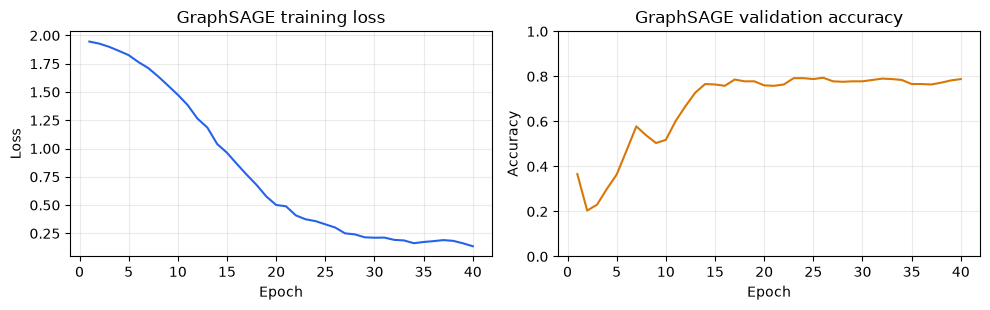

In [ ]:
seed_everything()


def build_adjacency(edge_index, num_nodes):
    neighbors = [[] for _ in range(num_nodes)]
    for src, dst in edge_index.t().tolist():
        if src != dst:
            neighbors[src].append(dst)
    return neighbors


def sample_fanouts(target_nodes, fanouts, neighbors):
    """GraphSAGE mini-batch: from the targets downward, keep `fanout` neighbors per node.

    The frontier at the next layer is the current nodes plus the nodes just drawn,
    so a node's own vector is still available when the layer concatenates.
    """
    frontiers = [None] * (len(fanouts) + 1)
    frontiers[-1] = target_nodes.detach().cpu()
    neighbor_lists = [None] * len(fanouts)
    for layer in reversed(range(len(fanouts))):
        nodes = frontiers[layer + 1]
        fanout = fanouts[layer]
        chosen = torch.empty(nodes.numel(), fanout, dtype=torch.long)
        for row, node in enumerate(nodes.tolist()):
            pool = neighbors[node]
            if not pool:
                chosen[row] = node
            else:
                pick = torch.randint(len(pool), (fanout,))
                chosen[row] = torch.tensor([pool[int(i)] for i in pick.tolist()])
        neighbor_lists[layer] = chosen
        frontiers[layer] = torch.unique(torch.cat([nodes, chosen.reshape(-1)]))
    return frontiers, neighbor_lists


def neighbor_mean(h, edge_index):
    """Mean of every neighbor. Used at test time, when nothing is sampled."""
    num_nodes, width = h.size()
    out = torch.zeros(num_nodes, width, device=h.device, dtype=h.dtype)
    src, dst = edge_index
    out.index_add_(0, dst, h[src])
    deg = torch.zeros(num_nodes, device=h.device, dtype=h.dtype)
    deg.index_add_(0, dst, torch.ones(dst.numel(), device=h.device, dtype=h.dtype))
    mean = out / deg.clamp_min(1).unsqueeze(1)
    mean[deg == 0] = h[deg == 0]
    return mean


class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        # The concatenation [own vector || neighbor mean] doubles the input width.
        self.lin1 = nn.Linear(in_channels * 2, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels * 2, out_channels)
        self.dropout = dropout

    def _step(self, h, nodes, neighbor_index, linear, activate):
        own = h[nodes]
        neigh = h[neighbor_index].mean(dim=1)
        out = linear(torch.cat([own, neigh], dim=-1))
        if activate:
            out = F.dropout(F.relu(out), p=self.dropout, training=self.training)
        return out

    def sampled_forward(self, x, frontiers, neighbor_lists):
        h = x
        for layer, linear in enumerate((self.lin1, self.lin2)):
            nodes = frontiers[layer + 1]
            out = self._step(h, nodes, neighbor_lists[layer], linear, activate=layer == 0)
            updated = h.new_zeros(x.size(0), out.size(1))
            updated[nodes] = out
            h = updated
        return h[frontiers[-1]]

    def full_forward(self, x, edge_index):
        h = x
        for layer, linear in enumerate((self.lin1, self.lin2)):
            neigh = neighbor_mean(h, edge_index)
            out = linear(torch.cat([h, neigh], dim=-1))
            if layer == 0:
                out = F.dropout(F.relu(out), p=self.dropout, training=self.training)
            h = out
        return h


adjacency = build_adjacency(data.edge_index, data.num_nodes)
x_all = data.x.to(DEVICE)
y_all = data.y.to(DEVICE)
full_edges = data.edge_index.to(DEVICE)
train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)

model = GraphSAGE(dataset.num_node_features, HIDDEN, dataset.num_classes, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def train_epoch():
    model.train()
    order = train_idx[torch.randperm(train_idx.numel())]
    total_loss = 0.0
    total_nodes = 0
    for start in range(0, order.numel(), BATCH_SIZE):
        batch = order[start : start + BATCH_SIZE]
        frontiers, neighbor_lists = sample_fanouts(batch, FANOUTS, adjacency)
        frontiers = [nodes.to(DEVICE) for nodes in frontiers]
        neighbor_lists = [neigh.to(DEVICE) for neigh in neighbor_lists]
        optimizer.zero_grad()
        logits = model.sampled_forward(x_all, frontiers, neighbor_lists)
        loss = F.cross_entropy(logits, y_all[batch.to(DEVICE)])
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * batch.numel()
        total_nodes += batch.numel()
    return total_loss / total_nodes


@torch.no_grad()
def predict():
    model.eval()
    return model.full_forward(x_all, full_edges).argmax(dim=-1).cpu()


fit("GraphSAGE", model, train_epoch, predict)

Target node 88: the full 2-hop neighborhood has 36 + 91 nodes. Fanout [10, 10] keeps 10 + 24.


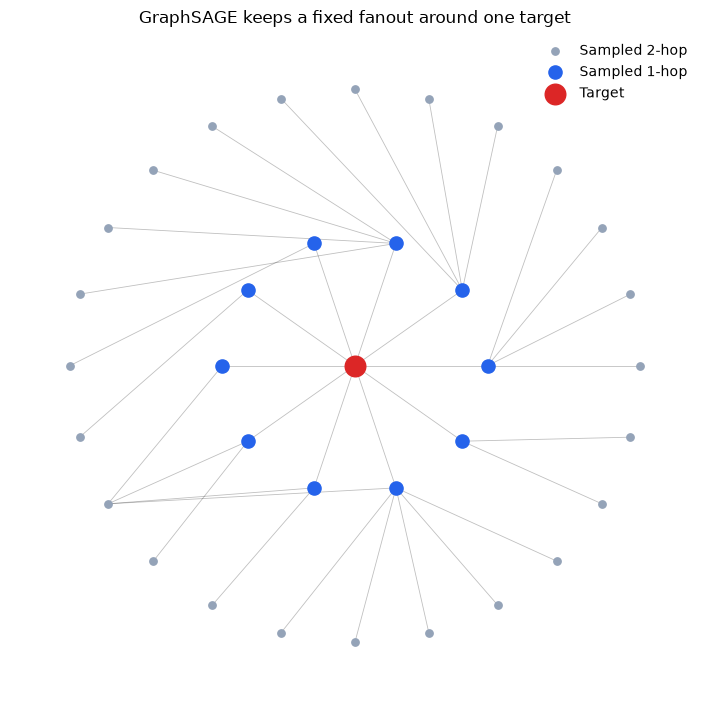

In [ ]:
adjacency = [[] for _ in range(data.num_nodes)]
for src, dst in data.edge_index.t().tolist():
    if src != dst and dst not in adjacency[src]:
        adjacency[src].append(dst)

degree_of = torch.tensor([len(nodes) for nodes in adjacency])
target = int(train_idx[degree_of[train_idx].argmax()])
rng = np.random.default_rng(SEED)
hop1 = rng.choice(adjacency[target], size=min(FANOUTS[0], len(adjacency[target])), replace=False)

sampled_edges = []
hop2 = []
for node in hop1:
    pool = adjacency[int(node)]
    if not pool:
        continue
    picked = rng.choice(pool, size=min(FANOUTS[1], len(pool)), replace=False)
    for other in picked:
        sampled_edges.append((int(node), int(other)))
        hop2.append(int(other))

full_hop1 = set(adjacency[target])
full_hop2 = set()
for node in full_hop1:
    full_hop2.update(adjacency[node])
full_hop2 -= full_hop1
full_hop2.discard(target)
kept_hop2 = set(hop2) - set(int(node) for node in hop1) - {target}
print(
    f"Target node {target}: the full 2-hop neighborhood has {len(full_hop1)} + {len(full_hop2)} nodes. "
    f"Fanout {FANOUTS} keeps {len(hop1)} + {len(kept_hop2)}."
)

graph = nx.Graph()
graph.add_node(target)
graph.add_edges_from((target, int(node)) for node in hop1)
graph.add_edges_from(sampled_edges)
position = {target: np.array([0.0, 0.0])}
for index, node in enumerate(hop1):
    angle = 2 * np.pi * index / len(hop1)
    position[int(node)] = np.array([np.cos(angle), np.sin(angle)])
outer = [node for node in graph.nodes if node not in position]
for index, node in enumerate(outer):
    angle = 2 * np.pi * index / max(len(outer), 1)
    position[node] = 2.15 * np.array([np.cos(angle), np.sin(angle)])

fig, ax = plt.subplots(figsize=(7.2, 7.2))
nx.draw_networkx_edges(graph, position, ax=ax, alpha=0.25, width=0.6)
nx.draw_networkx_nodes(graph, position, nodelist=outer, node_color="#94a3b8", node_size=28, ax=ax, label="Sampled 2-hop")
nx.draw_networkx_nodes(graph, position, nodelist=[int(node) for node in hop1], node_color="#2563eb", node_size=90, ax=ax, label="Sampled 1-hop")
nx.draw_networkx_nodes(graph, position, nodelist=[target], node_color="#dc2626", node_size=220, ax=ax, label="Target")
ax.set_title("GraphSAGE keeps a fixed fanout around one target")
ax.legend(frameon=False, loc="upper right")
ax.axis("off")
fig.tight_layout()
plt.show()


# 2. FastGCN

Node-wise fanouts still multiply. Depth $K$ with fanout $s$ touches $O(s^K)$ nodes. FastGCN draws one shared pool for the layer being estimated, so every labeled node reads the same sample.

Start from the usual GCN step. With $\hat{A} = \tilde{D}^{-1/2}(A+I)\tilde{D}^{-1/2}$,

$$
h^{(l+1)}(u) = \sum_{v=1}^{N} \hat{A}_{uv}\, h^{(l)}(v)\, W^{(l)}
$$

If node $v$ is drawn from a proposal $q$, the weight $\hat{A}_{uv}/q(v)$ puts that proposal back, and the sum is an expectation:

$$
h^{(l+1)}(u) = \mathbb{E}_{v \sim q}\left[ \frac{\hat{A}_{uv}}{q(v)} h^{(l)}(v) \right] W^{(l)}
$$

Draw $t$ nodes $v_1,\ldots,v_t$ from $q$ and replace the expectation by an average:

$$
h^{(l+1)}(u) \approx \left( \frac{1}{t} \sum_{j=1}^{t} \frac{\hat{A}_{u v_j}}{q(v_j)} h^{(l)}(v_j) \right) W^{(l)}
$$

The proposal is computed once from the columns of $\hat{A}$:

$$
q(v) = \frac{\|\hat{A}(:, v)\|^2}{\sum_{v'} \|\hat{A}(:, v')\|^2}
$$

On Cora the input matrix $X$ is fixed, so $\hat{A}X$ is computed once and the first layer is exact. The Monte Carlo average is only the next layer. `FASTGCN_SAMPLES = 400` is the sample size. The labeled nodes are the batch whose loss is computed. A Cora node has about six neighbors, so a few hundred samples is what makes that average nonzero for the training labels.


Epoch 01 | loss 1.946 | validation 31.6%
Epoch 10 | loss 1.917 | validation 17.8%
Epoch 20 | loss 1.793 | validation 28.8%
Epoch 30 | loss 1.755 | validation 63.8%
Epoch 40 | loss 1.627 | validation 59.4%
FastGCN | best epoch 32 | train 93.6% | val 71.0% | test 71.6%


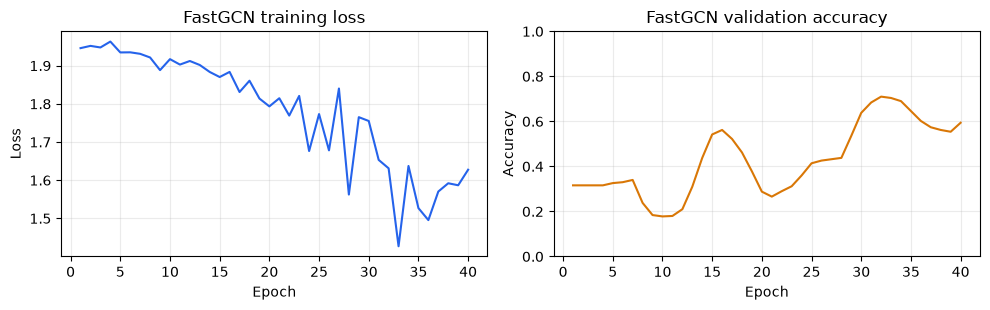

In [16]:
seed_everything()


def symmetric_adjacency(edge_index, num_nodes):
    """Dense D^{-1/2} (A + I) D^{-1/2}, the usual GCN neighborhood matrix."""
    edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    ones = torch.ones(edge_index.size(1))
    adj = torch.sparse_coo_tensor(edge_index, ones, (num_nodes, num_nodes)).coalesce()
    row, col = adj.indices()
    deg = torch.sparse.sum(adj, dim=1).to_dense().clamp_min(1)
    scale = deg.pow(-0.5)
    dense = torch.zeros(num_nodes, num_nodes)
    dense[row, col] = adj.values() * scale[row] * scale[col]
    return dense


def column_norm_distribution(kernel):
    """q(v) proportional to the squared column norm of A_hat."""
    scores = kernel.pow(2).sum(dim=0)
    return scores / scores.sum()


class FastGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def aggregate(self, h_source, source_ids, target_ids, kernel, q):
        # (1 / t) * sum_j kernel[u, v_j] / q(v_j) * h(v_j) estimates (kernel @ h)[u].
        block = kernel[target_ids][:, source_ids]
        weights = block / q[source_ids].clamp_min(1e-12)
        return (weights @ h_source) / source_ids.shape[0]

    def encode(self, ax):
        # ax = A_hat @ X is precomputed. This layer is exact.
        hidden = self.lin1(ax)
        return F.dropout(F.relu(hidden), p=self.dropout, training=self.training)

    def sampled_forward(self, ax, kernel, q, batch_ids, num_samples):
        hidden = self.encode(ax)
        chosen = torch.multinomial(q, num_samples, replacement=True)
        return self.lin2(self.aggregate(hidden[chosen], chosen, batch_ids, kernel, q))

    def full_forward(self, x, kernel):
        hidden = self.encode(kernel @ x)
        return self.lin2(kernel @ hidden)


kernel = symmetric_adjacency(data.edge_index, data.num_nodes).to(DEVICE)
q = column_norm_distribution(kernel).to(DEVICE)
x_all = data.x.to(DEVICE)
y_all = data.y.to(DEVICE)
# Input features never change, so this product is computed once.
ax_all = kernel @ x_all
train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)

model = FastGCN(dataset.num_node_features, HIDDEN, dataset.num_classes, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def train_epoch():
    model.train()
    order = train_idx[torch.randperm(train_idx.numel())]
    losses = []
    for start in range(0, order.numel(), BATCH_SIZE):
        batch_ids = order[start : start + BATCH_SIZE].to(DEVICE)
        optimizer.zero_grad()
        logits = model.sampled_forward(ax_all, kernel, q, batch_ids, FASTGCN_SAMPLES)
        loss = F.cross_entropy(logits, y_all[batch_ids])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(sum(losses) / len(losses))


@torch.no_grad()
def predict():
    model.eval()
    return model.full_forward(x_all, kernel).argmax(dim=-1).cpu()


fit("FastGCN", model, train_epoch, predict)


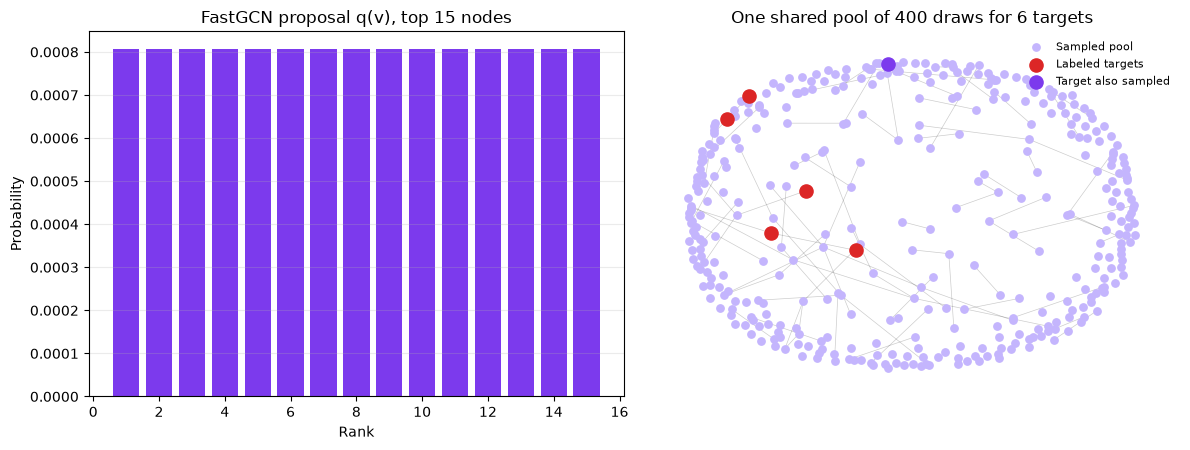

374 unique nodes were drawn for the hidden layer. Every target reads from this same pool, instead of growing its own neighbor tree.


In [19]:
# Left: the proposal q(v). Right: one shared pool used by every labeled node.
proposal = q.detach().cpu()
top_values, top_index = torch.topk(proposal, 15)
target_ids = train_idx[:6].to(DEVICE)
hidden_ids = torch.multinomial(q, FASTGCN_SAMPLES, replacement=True)
pool = set(hidden_ids.unique().tolist())
targets = set(target_ids.tolist())

graph = nx.Graph()
graph.add_nodes_from(targets | pool)
keep = targets | pool
for src, dst in data.edge_index.t().tolist():
    if src in keep and dst in keep and src != dst:
        graph.add_edge(src, dst)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(range(1, 16), top_values.numpy(), color="#7c3aed")
axes[0].set(title="FastGCN proposal q(v), top 15 nodes", xlabel="Rank", ylabel="Probability")
axes[0].grid(axis="y", alpha=0.25)

position = nx.spring_layout(graph, seed=SEED, k=0.35)
both = list(targets & pool)
only_targets = list(targets - pool)
only_pool = list(pool - targets)
nx.draw_networkx_edges(graph, position, ax=axes[1], alpha=0.2, width=0.5)
nx.draw_networkx_nodes(graph, position, nodelist=only_pool, node_color="#c4b5fd", node_size=28, ax=axes[1], label="Sampled pool")
nx.draw_networkx_nodes(graph, position, nodelist=only_targets, node_color="#dc2626", node_size=90, ax=axes[1], label="Labeled targets")
if both:
    nx.draw_networkx_nodes(graph, position, nodelist=both, node_color="#7c3aed", node_size=90, ax=axes[1], label="Target also sampled")
axes[1].set_title(f"One shared pool of {FASTGCN_SAMPLES} draws for 6 targets")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
axes[1].axis("off")
fig.tight_layout()
plt.show()
print(
    f"{len(pool)} unique nodes were drawn for the hidden layer. "
    "Every target reads from this same pool, instead of growing its own neighbor tree."
)


# 3. ASGCN

FastGCN's proposal does not depend on which nodes sit in the layer above. ASGCN draws one shared pool per layer, and that pool is chosen for those parents.

Let $P$ be the row-normalized adjacency with self-loops, so $P_{uv} = p(v \mid u)$ is the probability of stepping from $u$ to $v$ and each row sums to 1. A GCN average is an expectation under that row:

$$
(PH)_u = \sum_v p(v \mid u)\, h(v) = \mathbb{E}_{v \sim p(\cdot \mid u)}\big[h(v)\big]
$$

A separate neighbor sample for every parent would bring the fanout explosion back. ASGCN draws one set $v_1,\ldots,v_n$ for the whole layer, from a distribution $q(\cdot \mid U)$ that sees every parent in $U$, and corrects with an importance weight:

$$
\widehat{(PH)}_u = \frac{1}{n} \sum_{j=1}^{n} \frac{p(v_j \mid u)}{q(v_j \mid U)}\, h(v_j), \qquad v_j \sim q(\cdot \mid U)
$$

The variance of that estimator is smallest at

$$
q^*(v \mid U) \propto \sqrt{ \sum_{u \in U} p(v \mid u)^2 \, \|h(v)\|^2 }
$$

The hidden norm $\|h(v)\|$ is not known at sampling time. Sampling walks from the output down toward the input, while hidden states are computed in the other direction. The code drops the norm and keeps the part that depends only on the graph:

$$
q(v \mid U) \propto \sum_{u \in U} p(v \mid u)^2
$$

A node that many parents point to is drawn more often than a distant hub.

The second idea is a skip across one sampled layer. The nodes two steps down are already a 2-hop neighborhood of the batch, so reusing them costs no extra draw:

$$
h^{(l+1)}_u = W \left( \mathrm{Aggregate}\big(h^{(l)}\big) + \mathrm{Aggregate}\big(h^{(l-1)}\big) \right)
$$

In this network that is the output equation

$$
z_u = W_2 \left( \widehat{(PH)}_u + W_{\mathrm{skip}}\, \widehat{(PX)}_u \right)
$$

Add $\lambda \sum_l \mathrm{Var}\big(q^{(l)}\big)$ to the loss and learns $q$ with a small network. That penalty is left out here, so every model is trained with cross-entropy only and $q$ stays the closed form above.


Epoch 01 | loss 1.957 | validation 31.6%
Epoch 10 | loss 1.832 | validation 29.0%
Epoch 20 | loss 1.566 | validation 66.6%
Epoch 30 | loss 1.291 | validation 64.0%
Epoch 40 | loss 1.291 | validation 74.0%
ASGCN | best epoch 36 | train 95.0% | val 74.8% | test 76.8%


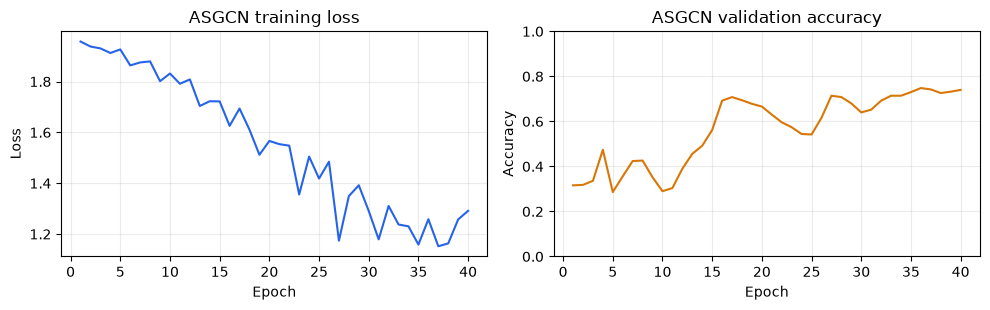

In [21]:
seed_everything()


def transition_matrix(edge_index, num_nodes):
    """Row-normalized A + I. Row u is the neighbor distribution p(v | u)."""
    edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    ones = torch.ones(edge_index.size(1))
    adj = torch.sparse_coo_tensor(edge_index, ones, (num_nodes, num_nodes)).coalesce()
    row, col = adj.indices()
    deg = torch.sparse.sum(adj, dim=1).to_dense().clamp_min(1)
    dense = torch.zeros(num_nodes, num_nodes)
    dense[row, col] = adj.values() / deg[row]
    return dense


class ASGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.skip = nn.Linear(in_channels, hidden_channels)
        self.dropout = dropout

    def sample_layer(self, parent_ids, transition, num_samples):
        # q(v | parents) grows when v is a likely neighbor of the parent set.
        scores = transition[parent_ids].pow(2).sum(dim=0)
        q = scores / scores.sum().clamp_min(1e-12)
        chosen = torch.multinomial(q, num_samples, replacement=True)
        return chosen, q

    def aggregate(self, h_source, source_ids, target_ids, transition, q):
        block = transition[target_ids][:, source_ids]
        weights = block / q[source_ids].clamp_min(1e-12)
        return (weights @ h_source) / source_ids.shape[0]

    def sampled_forward(self, x, transition, batch_ids, sample_sizes):
        input_size, hidden_size = sample_sizes
        # Top-down. The hidden sample depends on the batch, then the input sample depends on that.
        hidden_ids, q_hidden = self.sample_layer(batch_ids, transition, hidden_size)
        input_ids, q_input = self.sample_layer(hidden_ids, transition, input_size)
        hidden = self.aggregate(x[input_ids], input_ids, hidden_ids, transition, q_input)
        hidden = F.relu(self.lin1(hidden))
        hidden = F.dropout(hidden, p=self.dropout, training=self.training)
        near = self.aggregate(hidden, hidden_ids, batch_ids, transition, q_hidden)
        # The skip reuses the input sample, so we do not draw a second pool of nodes.
        far = self.skip(self.aggregate(x[input_ids], input_ids, batch_ids, transition, q_input))
        return self.lin2(near + far)

    def full_forward(self, x, transition):
        hidden = F.relu(self.lin1(transition @ x))
        hidden = F.dropout(hidden, p=self.dropout, training=self.training)
        near = transition @ hidden
        far = self.skip(transition @ x)
        return self.lin2(near + far)


transition = transition_matrix(data.edge_index, data.num_nodes).to(DEVICE)
x_all = data.x.to(DEVICE)
y_all = data.y.to(DEVICE)
train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)

model = ASGCN(dataset.num_node_features, HIDDEN, dataset.num_classes, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def train_epoch():
    model.train()
    order = train_idx[torch.randperm(train_idx.numel())]
    losses = []
    for start in range(0, order.numel(), BATCH_SIZE):
        batch_ids = order[start : start + BATCH_SIZE].to(DEVICE)
        optimizer.zero_grad()
        logits = model.sampled_forward(x_all, transition, batch_ids, LAYER_SAMPLES)
        loss = F.cross_entropy(logits, y_all[batch_ids])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(sum(losses) / len(losses))


@torch.no_grad()
def predict():
    model.eval()
    return model.full_forward(x_all, transition).argmax(dim=-1).cpu()


fit("ASGCN", model, train_epoch, predict)

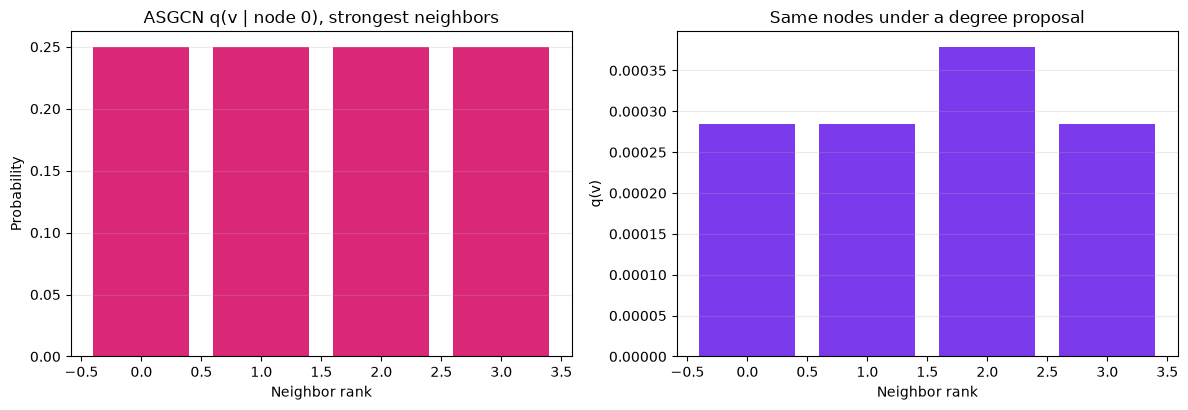

ASGCN ranks these neighbors by how strongly the parent points at them. The degree proposal on the right ranks the same nodes differently, because it never looks at the parent.


In [22]:
# For one parent, ASGCN's q sits on that parent's neighbors. Degree-based q does not.
parent = int(train_idx[0])
parent_ids = torch.tensor([parent], device=DEVICE)
scores = transition[parent_ids].pow(2).sum(dim=0)
scores = scores / scores.sum().clamp_min(1e-12)
support = (scores > 0).nonzero(as_tuple=False).view(-1)
top_count = min(20, support.numel())
top_scores, local_index = torch.topk(scores[support], top_count)
neighbor_ids = support[local_index].detach().cpu()
chosen, _ = model.sample_layer(parent_ids, transition, LAYER_SAMPLES[1])
chosen_set = set(chosen.tolist())
bar_colors = ["#db2777" if int(node) in chosen_set else "#f9a8d4" for node in neighbor_ids.tolist()]

degree_q = degree(data.edge_index[1], num_nodes=data.num_nodes).clamp_min(1)
degree_q = (degree_q / degree_q.sum()).detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(range(top_count), top_scores.detach().cpu().numpy(), color=bar_colors)
axes[0].set(title=f"ASGCN q(v | node {parent}), strongest neighbors", xlabel="Neighbor rank", ylabel="Probability")
axes[0].grid(axis="y", alpha=0.25)
axes[1].bar(range(top_count), degree_q[neighbor_ids].numpy(), color="#7c3aed")
axes[1].set(title="Same nodes under a degree proposal", xlabel="Neighbor rank", ylabel="q(v)")
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print(
    "ASGCN ranks these neighbors by how strongly the parent points at them. "
    "The degree proposal on the right ranks the same nodes differently, because it never looks at the parent."
)


## 4. GraphSAINT

GraphSAINT does not sample neighbors of one node, and it does not sample a pool per layer. It samples a subgraph and runs a normal GNN on that subgraph.

Random walks of length `WALK_LENGTH` start at `BATCH_SIZE` roots. The batch is the induced subgraph of the visited nodes, so the piece stays connected. A uniform bag of the same number of nodes would not. Inside the subgraph the update is an ordinary two-layer graph convolution. The method is the sampler, plus the two corrections below.

Walks visit popular nodes more often. Training those nodes as often as rare ones would bias the gradient. Let $p_v$ be the probability that node $v$ appears in a sampled subgraph, and $p_{uv}$ the probability that edge $(u,v)$ is kept. Rescale the loss and the messages:

$$
\lambda_v = |V|\, p_v, \qquad
\mathcal{L}_{\mathrm{batch}} = \sum_{v \in V_s \cap V_{\mathrm{train}}} \frac{1}{\lambda_v}\, \ell(z_v, y_v)
$$

$$
\alpha_{uv} = \frac{p_{uv}}{p_v}
$$

`sample_coverage` asks the loader to estimate those probabilities from repeated walks. `node_norm` stores the loss weight $1/\lambda_v$, and `edge_norm` stores $\alpha_{uv}$. Each message is multiplied by `edge_norm * edge_weight`, and the base edge weight is $1/\deg(v)$, so a sum over neighbors behaves like a mean. The training loss also divides by the total weight,

$$
\mathcal{L} = \frac{\sum_v \texttt{node\_norm}_v\, \ell_v}{\sum_v \texttt{node\_norm}_v}
$$

so a rarely visited node still counts for more, while the number Adam sees stays on the same scale as the other models. At test time nothing is subsampled, and only the base edge weight remains.


Estimating how often random walks visit each node and edge...
Epoch 01 | loss 1.957 | validation 17.4%
Epoch 10 | loss 0.960 | validation 71.6%
Epoch 20 | loss 0.335 | validation 66.8%
Epoch 30 | loss 0.269 | validation 73.0%
Epoch 40 | loss 0.136 | validation 72.4%
GraphSAINT | best epoch 25 | train 100.0% | val 79.2% | test 80.1%


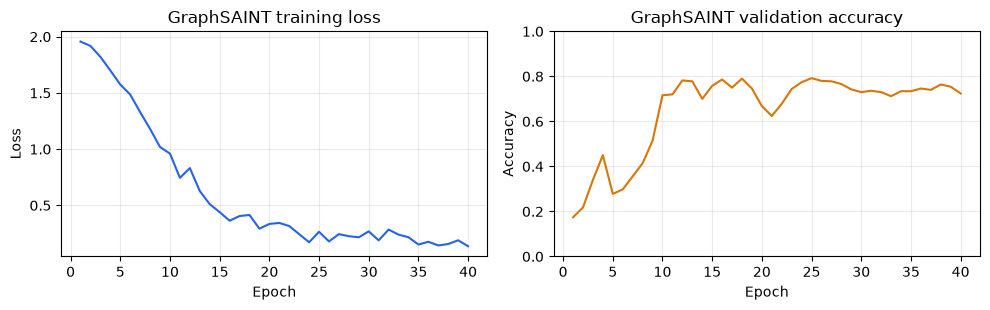

In [ ]:
seed_everything()


def build_adjacency(edge_index, num_nodes):
    neighbors = [[] for _ in range(num_nodes)]
    for src, dst in edge_index.t().tolist():
        if src != dst:
            neighbors[src].append(dst)
    return neighbors


def random_walk_nodes(neighbors, num_starts, walk_length, num_nodes):
    """Nodes visited by `num_starts` walks. The subgraph is everything they touch."""
    current = torch.randint(0, num_nodes, (num_starts,)).tolist()
    visited = set(current)
    for _ in range(walk_length):
        nxt = []
        for node in current:
            pool = neighbors[node]
            step = node if not pool else pool[int(torch.randint(len(pool), ()))]
            nxt.append(step)
            visited.add(step)
        current = nxt
    return torch.tensor(sorted(visited), dtype=torch.long)


def induced_edges(node_ids, edge_index, num_nodes):
    """Edges with both ends inside `node_ids`, relabeled to 0..len(node_ids)-1."""
    inside = torch.zeros(num_nodes, dtype=torch.bool)
    inside[node_ids] = True
    src, dst = edge_index
    keep = inside[src] & inside[dst]
    new_id = torch.full((num_nodes,), -1, dtype=torch.long)
    new_id[node_ids] = torch.arange(node_ids.numel())
    sub_edges = torch.stack([new_id[src[keep]], new_id[dst[keep]]], dim=0)
    return sub_edges, keep


class WalkBatch:
    def __init__(self, x, y, edge_index, edge_weight, edge_norm, node_norm, train_mask):
        self.x = x
        self.y = y
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.edge_norm = edge_norm
        self.node_norm = node_norm
        self.train_mask = train_mask
        self.num_nodes = int(x.size(0))
        self.num_edges = int(edge_index.size(1))


class GraphConvScratch(nn.Module):
    """Weighted sum of neighbor vectors, plus a separate linear map of the node itself."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.neighbor = nn.Linear(in_channels, out_channels, bias=False)
        self.root = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight):
        src, dst = edge_index
        messages = self.neighbor(x)
        out = torch.zeros(x.size(0), messages.size(1), device=x.device, dtype=messages.dtype)
        if src.numel():
            out.index_add_(0, dst, messages[src] * edge_weight.unsqueeze(1))
        return out + self.root(x)


class GraphSAINTNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.conv1 = GraphConvScratch(in_channels, hidden_channels)
        self.conv2 = GraphConvScratch(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.dropout(F.relu(x), p=self.dropout, training=self.training)
        return self.conv2(x, edge_index, edge_weight)


saint_neighbors = build_adjacency(data.edge_index, data.num_nodes)
src, dst = data.edge_index
in_degree = torch.zeros(data.num_nodes)
in_degree.index_add_(0, dst, torch.ones(dst.numel()))
# A neighbor shared by many nodes is down-weighted. Sampling corrections sit on top of this.
base_edge_weight = in_degree.clamp_min(1).reciprocal()[dst]


def estimate_sampling_norms():
    """Count how often walks visit each node and edge. That estimates p_v and p_uv."""
    node_count = torch.zeros(data.num_nodes)
    edge_count = torch.zeros(data.edge_index.size(1))
    seen = 0
    n_subgraphs = 0
    target = data.num_nodes * SAMPLE_COVERAGE
    while seen < target:
        nodes = random_walk_nodes(saint_neighbors, BATCH_SIZE, WALK_LENGTH, data.num_nodes)
        _, keep = induced_edges(nodes, data.edge_index, data.num_nodes)
        node_count[nodes] += 1
        edge_count[keep] += 1
        seen += int(nodes.numel())
        n_subgraphs += 1
    node_norm = n_subgraphs / node_count.clamp_min(0.1) / data.num_nodes
    edge_norm = node_count[src] / edge_count.clamp_min(1e-6)
    edge_norm = edge_norm.clamp(max=1e4)
    edge_norm[edge_count == 0] = 0.1
    return node_norm, edge_norm


print("Estimating how often random walks visit each node and edge...")
node_norm, edge_norm = estimate_sampling_norms()


def make_walk_batch():
    nodes = random_walk_nodes(saint_neighbors, BATCH_SIZE, WALK_LENGTH, data.num_nodes)
    sub_edges, keep = induced_edges(nodes, data.edge_index, data.num_nodes)
    return WalkBatch(
        x=data.x[nodes],
        y=data.y[nodes],
        edge_index=sub_edges,
        edge_weight=base_edge_weight[keep],
        edge_norm=edge_norm[keep],
        node_norm=node_norm[nodes],
        train_mask=data.train_mask[nodes],
    )


model = GraphSAINTNet(dataset.num_node_features, HIDDEN, dataset.num_classes, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def train_epoch():
    model.train()
    losses = []
    for _ in range(SAINT_STEPS):
        sampled = make_walk_batch()
        if not bool(sampled.train_mask.any()):
            continue
        optimizer.zero_grad()
        weight = (sampled.edge_norm * sampled.edge_weight).to(DEVICE)
        logits = model(sampled.x.to(DEVICE), sampled.edge_index.to(DEVICE), weight)
        labeled = sampled.train_mask
        # node_norm is larger for nodes the walks rarely visit.
        weights = sampled.node_norm[labeled].to(DEVICE)
        per_node = F.cross_entropy(logits, sampled.y.to(DEVICE), reduction="none")[labeled.to(DEVICE)]
        loss = (per_node * weights).sum() / weights.sum().clamp_min(1e-12)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))
    if not losses:
        raise RuntimeError("No training labels were sampled. Increase BATCH_SIZE or SAINT_STEPS.")
    return float(sum(losses) / len(losses))


@torch.no_grad()
def predict():
    model.eval()
    logits = model(data.x.to(DEVICE), data.edge_index.to(DEVICE), base_edge_weight.to(DEVICE))
    return logits.argmax(dim=-1).cpu()


fit("GraphSAINT", model, train_epoch, predict)


One random-walk subgraph: 331 nodes, 718 edges, 18 of them have a training label.


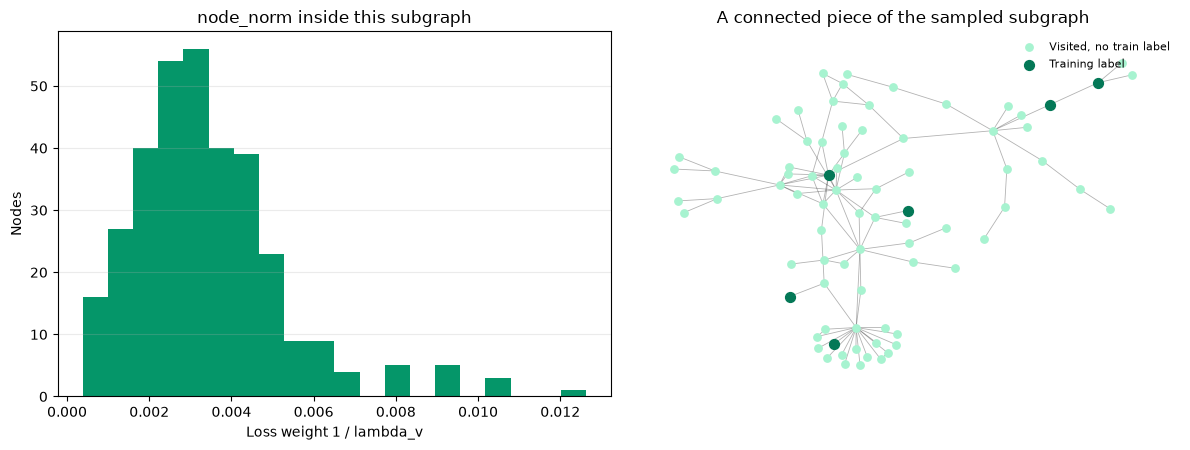

In [11]:
sampled = make_walk_batch()
train_count = int(sampled.train_mask.sum())
print(
    f"One random-walk subgraph: {sampled.num_nodes} nodes, {sampled.num_edges} edges, "
    f"{train_count} of them have a training label."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(sampled.node_norm.cpu().numpy(), bins=20, color="#059669")
axes[0].set(title="node_norm inside this subgraph", xlabel="Loss weight 1 / lambda_v", ylabel="Nodes")
axes[0].grid(axis="y", alpha=0.25)

picture = nx.Graph()
picture.add_nodes_from(range(sampled.num_nodes))
picture.add_edges_from(sampled.edge_index.t().tolist())
# A few hundred nodes is enough to see that the walks stayed connected.
largest = max(nx.connected_components(picture), key=len)
start = next(iter(largest))
reached = list(nx.bfs_tree(picture, start))[:80]
component = picture.subgraph(reached).copy()
position = nx.spring_layout(component, seed=SEED)
train_nodes = [node for node in component.nodes if bool(sampled.train_mask[node])]
other_nodes = [node for node in component.nodes if node not in train_nodes]
nx.draw_networkx_edges(component, position, ax=axes[1], alpha=0.3, width=0.6)
nx.draw_networkx_nodes(component, position, nodelist=other_nodes, node_color="#a7f3d0", node_size=28, ax=axes[1], label="Visited, no train label")
if train_nodes:
    nx.draw_networkx_nodes(component, position, nodelist=train_nodes, node_color="#047857", node_size=50, ax=axes[1], label="Training label")
axes[1].set_title("A connected piece of the sampled subgraph")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
axes[1].axis("off")
fig.tight_layout()
plt.show()


# 5. ClusterGCN

A 2-layer GCN needs the 2-hop neighborhood before it can score one node, and most of those embeddings are then thrown away. ClusterGCN looks for a batch in which the embeddings are reused: a dense piece of the graph, so a neighbor of a training node is another node in the same batch.

The nodes are cut into $C$ groups $V_1,\ldots,V_C$.

One group alone is a bad batch. Every edge that leaves the group is deleted, and similar labels tend to sit together, so the labels inside the batch do not match the rest of the graph. The fix is to draw $b$ groups and keep every edge inside their union:

$$
V_{\mathrm{batch}} = \bigcup_{t=1}^{b} V_{c_t}, \qquad
E_{\mathrm{batch}} = \{(u,v) \in E : u \in V_{\mathrm{batch}},\; v \in V_{\mathrm{batch}}\}
$$

`CLUSTERS_PER_BATCH = 2` is that $b$. The network on this subgraph is a plain two-layer GCN,

$$
H^{(l+1)} = \sigma\left( \hat{A}_{\mathrm{batch}} H^{(l)} W^{(l)} \right)
$$

where $\hat{A}_{\mathrm{batch}}$ is the normalized adjacency of $E_{\mathrm{batch}}$. The loss uses only training labels inside the batch. At test time the same GCN runs on the full edge set.


Partitioning Cora into 8 clusters...
Cluster sizes: [643, 556, 424, 406, 179, 156, 174, 170]
Epoch 01 | loss 1.957 | validation 31.6%
Epoch 10 | loss 1.583 | validation 57.4%
Epoch 20 | loss 0.814 | validation 79.0%
Epoch 30 | loss 0.449 | validation 79.2%
Epoch 40 | loss 0.310 | validation 78.8%
ClusterGCN | best epoch 31 | train 98.6% | val 80.0% | test 80.6%


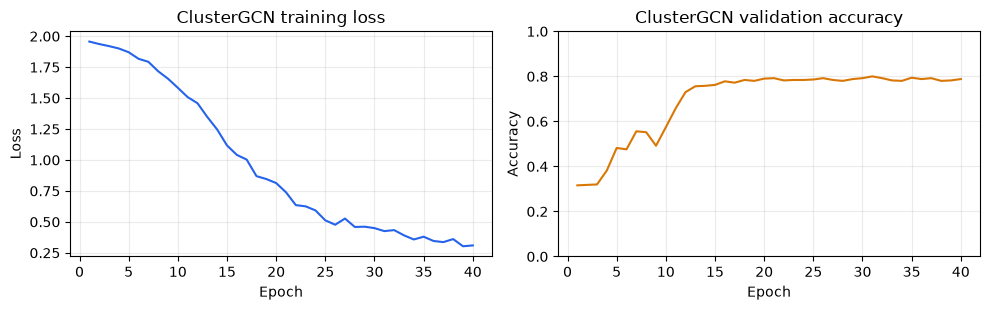

In [ ]:
seed_everything()


def partition_nodes(edge_index, num_nodes, num_clusters, seed):
    """Grow same-sized clusters by walking out from seeds.
    """
    neighbors = [[] for _ in range(num_nodes)]
    for src, dst in edge_index.t().tolist():
        if src != dst:
            neighbors[src].append(dst)

    rng = np.random.default_rng(seed)
    for nodes in neighbors:
        rng.shuffle(nodes)

    labels = np.full(num_nodes, -1, dtype=np.int64)
    unlabeled = set(range(num_nodes))
    target = int(np.ceil(num_nodes / num_clusters))

    def grow(start, cluster, limit):
        queue = [start]
        labels[start] = cluster
        unlabeled.remove(start)
        filled = 1
        head = 0
        while head < len(queue) and filled < limit:
            current = queue[head]
            head += 1
            for nxt in neighbors[current]:
                if labels[nxt] != -1:
                    continue
                labels[nxt] = cluster
                unlabeled.remove(nxt)
                queue.append(nxt)
                filled += 1
                if filled >= limit:
                    break

    for cluster in range(num_clusters):
        if not unlabeled:
            break
        start = int(rng.choice(np.array(list(unlabeled))))
        grow(start, cluster, target)

    # Nodes a full cluster could not reach join the smallest neighboring cluster.
    while unlabeled:
        start = unlabeled.pop()
        nearby = [labels[node] for node in neighbors[start] if labels[node] >= 0]
        if nearby:
            counts = {cluster: nearby.count(cluster) for cluster in set(nearby)}
            chosen = max(counts, key=counts.get)
        else:
            sizes = np.bincount(labels[labels >= 0], minlength=num_clusters)
            chosen = int(np.argmin(sizes))
        labels[start] = chosen

    return torch.from_numpy(labels).long()


def gcn_aggregate(x, edge_index):
    """Multiply by D^{-1/2} (A + I) D^{-1/2}. Self-loops are added here."""
    num_nodes = x.size(0)
    loops = torch.arange(num_nodes, device=x.device)
    row = torch.cat([edge_index[0], loops])
    col = torch.cat([edge_index[1], loops])
    deg = torch.zeros(num_nodes, device=x.device, dtype=x.dtype)
    deg.index_add_(0, row, torch.ones(row.numel(), device=x.device, dtype=x.dtype))
    scale = deg.clamp_min(1).pow(-0.5)
    weight = scale[row] * scale[col]
    out = torch.zeros_like(x)
    out.index_add_(0, row, x[col] * weight.unsqueeze(1))
    return out


class ClusterGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.lin1(gcn_aggregate(x, edge_index))
        x = F.dropout(F.relu(x), p=self.dropout, training=self.training)
        return self.lin2(gcn_aggregate(x, edge_index))


print(f"Partitioning {DATASET_NAME} into {NUM_CLUSTERS} clusters...")
cluster_id = partition_nodes(data.edge_index, data.num_nodes, NUM_CLUSTERS, SEED)
print("Cluster sizes:", torch.bincount(cluster_id).tolist())

model = ClusterGCN(dataset.num_node_features, HIDDEN, dataset.num_classes, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def train_epoch():
    model.train()
    order = torch.randperm(NUM_CLUSTERS)
    losses = []
    for start in range(0, NUM_CLUSTERS, CLUSTERS_PER_BATCH):
        chosen = order[start : start + CLUSTERS_PER_BATCH]
        node_ids = torch.isin(cluster_id, chosen).nonzero(as_tuple=False).view(-1)
        # The induced subgraph keeps edges that run between the chosen clusters.
        sub_edges, _ = subgraph(
            node_ids, data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes
        )
        mask = data.train_mask[node_ids].to(DEVICE)
        if not bool(mask.any()):
            continue
        optimizer.zero_grad()
        logits = model(data.x[node_ids].to(DEVICE), sub_edges.to(DEVICE))
        loss = F.cross_entropy(logits[mask], data.y[node_ids].to(DEVICE)[mask])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    if not losses:
        raise RuntimeError("No cluster batch contained a training node.")
    return float(sum(losses) / len(losses))


@torch.no_grad()
def predict():
    model.eval()
    logits = model(data.x.to(DEVICE), data.edge_index.to(DEVICE))
    return logits.argmax(dim=-1).cpu()


fit("ClusterGCN", model, train_epoch, predict)


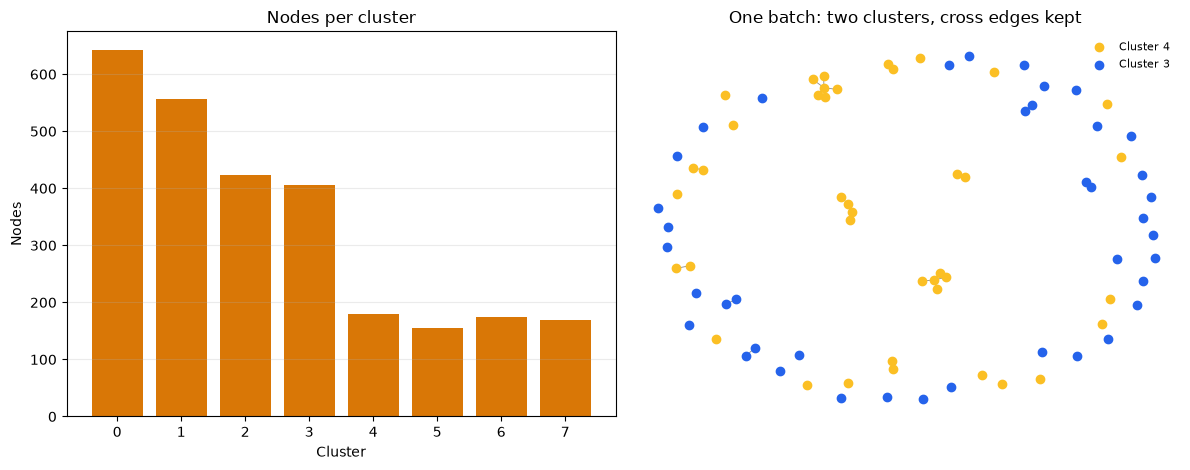

Clusters 4 and 3 have 179 and 406 nodes. The drawing shows 40 nodes from each. Red edges are the between-cluster links a single cluster would have dropped.


In [13]:
sizes = torch.bincount(cluster_id)
# Two middle-sized groups, so the picture is a batch rather than a pair of giant components.
order = torch.argsort(sizes)
left, right = int(order[len(order) // 2 - 1]), int(order[len(order) // 2])
rng = np.random.default_rng(SEED)
picked = []
local_group = []
for group, cluster in enumerate((left, right)):
    members = (cluster_id == cluster).nonzero(as_tuple=False).view(-1).numpy()
    take = min(40, len(members))
    choice = rng.choice(members, size=take, replace=False)
    picked.extend(int(node) for node in choice)
    local_group.extend([group] * take)
node_ids = torch.tensor(picked)
sub_edges, _ = subgraph(node_ids, data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes)
local_group = torch.tensor(local_group)

graph = nx.Graph()
graph.add_nodes_from(range(node_ids.numel()))
graph.add_edges_from(sub_edges.t().tolist())
internal, crossing = [], []
for src, dst in sub_edges.t().tolist():
    (internal if local_group[src] == local_group[dst] else crossing).append((src, dst))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].bar(range(NUM_CLUSTERS), sizes.numpy(), color="#d97706")
axes[0].set(title="Nodes per cluster", xlabel="Cluster", ylabel="Nodes")
axes[0].grid(axis="y", alpha=0.25)

position = nx.spring_layout(graph, seed=SEED)
nx.draw_networkx_edges(graph, position, edgelist=internal, ax=axes[1], alpha=0.25, width=0.6)
nx.draw_networkx_edges(graph, position, edgelist=crossing, ax=axes[1], edge_color="#dc2626", width=1.4, label="Edge between the two clusters")
for group, color, name in ((0, "#fbbf24", f"Cluster {left}"), (1, "#2563eb", f"Cluster {right}")):
    nodelist = (local_group == group).nonzero(as_tuple=False).view(-1).tolist()
    nx.draw_networkx_nodes(graph, position, nodelist=nodelist, node_color=color, node_size=36, ax=axes[1], label=name)
axes[1].set_title("One batch: two clusters, cross edges kept")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
axes[1].axis("off")
fig.tight_layout()
plt.show()
print(
    f"Clusters {left} and {right} have {int(sizes[left])} and {int(sizes[right])} nodes. "
    f"The drawing shows 40 nodes from each. Red edges are the between-cluster links a single cluster would have dropped."
)


## How the five runs compare

These numbers are not a leaderboard. Cora's public training set has 140 labeled nodes, so a few points of test accuracy can move when the seed changes. Read the table as a check that every sampler trained, and as a reminder of what each method spends its budget on: neighbors of one node, a shared pool per layer, or a whole subgraph.


Model              Train       Val      Test
GraphSAGE         100.0%     79.4%     80.3%
FastGCN            93.6%     71.0%     71.6%
ASGCN              95.0%     74.8%     76.8%
GraphSAINT        100.0%     79.2%     80.1%
ClusterGCN         98.6%     80.0%     80.6%


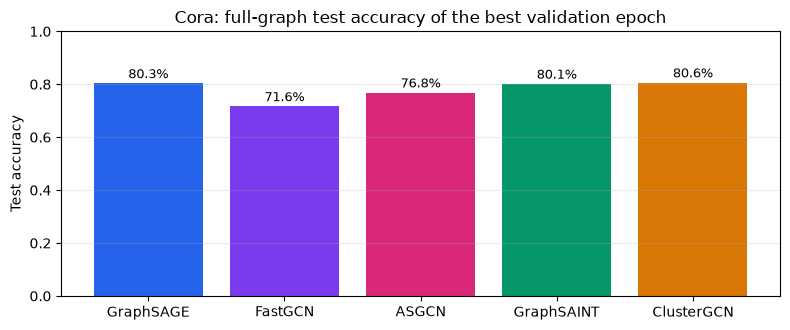

In [14]:
order = ["GraphSAGE", "FastGCN", "ASGCN", "GraphSAINT", "ClusterGCN"]
print(f"{'Model':<14}{'Train':>10}{'Val':>10}{'Test':>10}")
for name in order:
    scores = results[name]
    print(f"{name:<14}{scores['train']:>10.1%}{scores['val']:>10.1%}{scores['test']:>10.1%}")

test_scores = [results[name]["test"] for name in order]
colors = ["#2563eb", "#7c3aed", "#db2777", "#059669", "#d97706"]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(order, test_scores, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Test accuracy")
ax.set_title(f"{DATASET_NAME}: full-graph test accuracy of the best validation epoch")
ax.grid(axis="y", alpha=0.25)
for index, value in enumerate(test_scores):
    ax.text(index, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()
